Các bước thực hiện trong colab này:
+ Đọc dữ liệu
+ Clean data
+ Xử lý outlier bằng Zscore
+ Cho vào SMOTE
+ Chia dữ liệu train, test
+ Scale tập train, test
+ Cho vào mô hình
- tỉ lệ trên tập test cân bằng là

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/DATN/fetal_health.csv'
data = pd.read_csv(file_path)
display(data.head())

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [4]:
negative_values_found = False
for column in data.select_dtypes(include=['number']).columns:
    negative_count = (data[column] < 0).sum()
    if negative_count > 0:
        print(f"Cột '{column}' có {negative_count} giá trị nhỏ hơn 0.")
        negative_values_found = True

if not negative_values_found:
    print("Không tìm thấy giá trị nào nhỏ hơn 0 trong các cột số.")

Cột 'histogram_tendency' có 165 giá trị nhỏ hơn 0.


In [5]:
data["histogram_tendency"].value_counts()

,count
histogram_tendency,
0.0,1115
1.0,846
-1.0,165


In [6]:
data["fetal_health"].value_counts()

,count
fetal_health,
1.0,1655
2.0,295
3.0,176


Clean data

In [7]:
data.duplicated().sum()

np.int64(13)

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.isna().sum().sum()

np.int64(0)

In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2113.0,133.304780,9.837451,106.0,126.000,133.000,140.000,160.000
accelerations,2113.0,0.003188,0.003871,0.0,0.000,0.002,0.006,0.019
fetal_movement,2113.0,0.009517,0.046804,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2113.0,0.004387,0.002941,0.0,0.002,0.005,0.007,0.015
light_decelerations,2113.0,0.001901,0.002966,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2113.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2113.0,0.000159,0.000592,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2113.0,46.993848,17.177782,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2113.0,1.335021,0.884368,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2113.0,9.795078,18.337073,0.0,0.000,0.000,11.000,91.000


Outlier Zscore

In [12]:
from scipy.stats import zscore
import numpy as np
import pandas as pd

# Tách cột đầu vào và cột đầu ra
X = data.drop(columns=['fetal_health'])
y = data['fetal_health']

# Chỉ lấy các cột số trong X
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Tính Z-score cho các cột số
z_scores = np.abs(zscore(X[num_cols], nan_policy='omit'))

# Nếu chỉ có 1 cột số thì đưa về DataFrame cho đồng nhất
if len(num_cols) == 1:
    z_scores = pd.DataFrame(z_scores, columns=num_cols, index=X.index)
else:
    z_scores = pd.DataFrame(z_scores, columns=num_cols, index=X.index)

# Đặt ngưỡng Z-score
threshold = 3.5

# Giữ lại các dòng không có outlier
mask = (z_scores < threshold).all(axis=1)

X_clean = X[mask]
y_clean = y[mask]

# Ghép lại thành dataframe mới nếu cần
data_clean = pd.concat([X_clean, y_clean], axis=1)

print("Kích thước trước khi xử lý:", data.shape)
print("Kích thước sau khi xử lý:", data_clean.shape)

Kích thước trước khi xử lý: (2113, 22)
Kích thước sau khi xử lý: (1920, 22)


In [13]:
data_clean["fetal_health"].value_counts()

,count
fetal_health,
1.0,1554
2.0,279
3.0,87


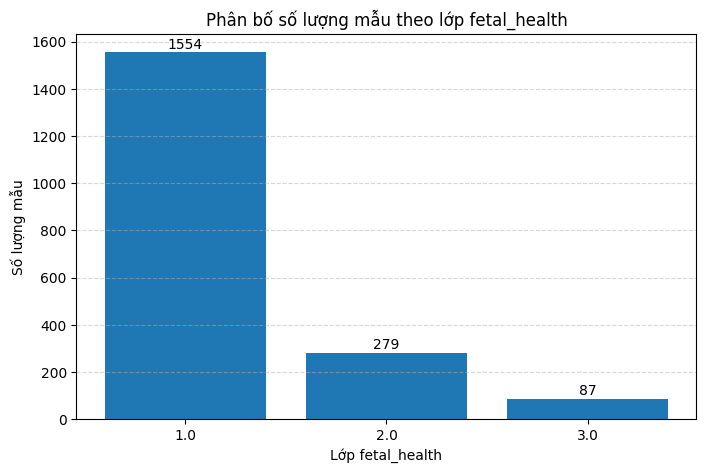

In [14]:
import matplotlib.pyplot as plt

# Đếm số lượng mẫu của từng lớp
class_counts = data_clean['fetal_health'].value_counts().sort_index()

# Vẽ biểu đồ cột
plt.figure(figsize=(8,5))
bars = plt.bar(class_counts.index.astype(str), class_counts.values)

# Hiển thị số trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval),
             ha='center', va='bottom', fontsize=10)

plt.title('Phân bố số lượng mẫu theo lớp fetal_health')
plt.xlabel('Lớp fetal_health')
plt.ylabel('Số lượng mẫu')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [15]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score
)

target_col = 'fetal_health'

print("Kích thước data gốc:", data_clean.shape)
display(data_clean.head())

# =============================
# 2. Tách X, y từ toàn bộ data
# =============================
X = data_clean.drop(columns=[target_col]).copy()
y = data_clean[target_col].copy().astype(int)

# print("Kích thước data gốc:", data.shape)
# display(data.head())

# # =============================
# # 2. Tách X, y từ toàn bộ data
# # =============================
# X = data.drop(columns=[target_col]).copy()
# y = data[target_col].copy().astype(int)



print("\nPhân bố lớp ban đầu:")
print(y.value_counts().sort_index())

# =============================
# 3. SMOTE trên toàn bộ data
# =============================
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42,
    k_neighbors=5
)

X_smote, y_smote = smote.fit_resample(X, y)

X_smote = pd.DataFrame(X_smote, columns=X.columns)
y_smote = pd.Series(y_smote, name=target_col)

print("\nPhân bố lớp sau SMOTE toàn bộ data:")
print(y_smote.value_counts().sort_index())

print("\nKích thước sau SMOTE:")
print("X_smote:", X_smote.shape)
print("y_smote:", y_smote.shape)

# =============================
# 4. Chia train/test sau khi SMOTE
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X_smote,
    y_smote,
    test_size=0.2,
    random_state=42,
    stratify=y_smote
)

print("\nPhân bố y_train:")
print(y_train.value_counts().sort_index())

print("\nPhân bố y_test:")
print(y_test.value_counts().sort_index())

# =============================
# 5. Scale sau khi chia
# =============================
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("\nĐã scale xong dữ liệu")

# =============================
# 6. Train model
# =============================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

# =============================
# 7. Đánh giá
# =============================
print("\n=== KẾT QUẢ ===")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nKQ FOR EXCEL\n")
print("Precision weighted:", precision_score(y_test, y_pred, average='weighted'))
print("Recall weighted:", recall_score(y_test, y_pred, average='weighted'))
print("F1 weighted:", f1_score(y_test, y_pred, average='weighted'))

print("Precision macro:", precision_score(y_test, y_pred, average='macro'))
print("Recall macro:", recall_score(y_test, y_pred, average='macro'))
print("F1 macro:", f1_score(y_test, y_pred, average='macro'))
print("\nDetail about one class:")


print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nConfusion Matrix (normalize='true'):")
print(confusion_matrix(y_test, y_pred, normalize='true'))

Kích thước data gốc: (1920, 22)


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0



Phân bố lớp ban đầu:
fetal_health
1    1554
2     279
3      87
Name: count, dtype: int64

Phân bố lớp sau SMOTE toàn bộ data:
fetal_health
1    1554
2    1554
3    1554
Name: count, dtype: int64

Kích thước sau SMOTE:
X_smote: (4662, 21)
y_smote: (4662,)

Phân bố y_train:
fetal_health
1    1243
2    1243
3    1243
Name: count, dtype: int64

Phân bố y_test:
fetal_health
1    311
2    311
3    311
Name: count, dtype: int64

Đã scale xong dữ liệu

=== KẾT QUẢ ===
Accuracy: 0.9839228295819936

KQ FOR EXCEL

Precision weighted: 0.9839829978374884
Recall weighted: 0.9839228295819936
F1 weighted: 0.9839205142057654
Precision macro: 0.9839829978374887
Recall macro: 0.9839228295819936
F1 macro: 0.9839205142057654

Detail about one class:
Balanced Accuracy: 0.9839228295819936
Macro F1: 0.9839205142057654

Classification Report:
              precision    recall  f1-score   support

           1     0.9902    0.9743    0.9822       311
           2     0.9713    0.9807    0.9760       311
     

XGBoot

In [16]:
y_train = y_train.astype(int) - 1
y_test = y_test.astype(int) - 1

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Khởi tạo model XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',   # dùng cho phân loại nhiều lớp
    num_class=len(y_train.unique()),
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

# Train model
xgb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_xg = xgb_model.predict(X_test_scaled)

# Đánh giá
print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print("Precision weighted:", precision_score(y_test, y_pred_xg, average='weighted'))
print("Recall weighted:", recall_score(y_test, y_pred_xg, average='weighted'))
print("F1 weighted:", f1_score(y_test, y_pred_xg, average='weighted'))

print("Precision macro:", precision_score(y_test, y_pred_xg, average='macro'))
print("Recall macro:", recall_score(y_test, y_pred_xg, average='macro'))
print("F1 macro:", f1_score(y_test, y_pred_xg, average='macro'))

print("\nDetail about one class:")
print("Classification Report:\n", classification_report(y_test, y_pred_xg))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xg))

Accuracy: 0.9882100750267953
Precision weighted: 0.9883282340934619
Recall weighted: 0.9882100750267953
F1 weighted: 0.9882266844610088
Precision macro: 0.9883282340934619
Recall macro: 0.9882100750267954
F1 macro: 0.9882266844610088

Detail about one class:
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       311
           1       0.97      0.99      0.98       311
           2       0.99      0.99      0.99       311

    accuracy                           0.99       933
   macro avg       0.99      0.99      0.99       933
weighted avg       0.99      0.99      0.99       933


Confusion Matrix:
 [[305   6   0]
 [  1 308   2]
 [  0   2 309]]


Biểu diễn dữ liệu sau khi smote

In [18]:
import pandas as pd

df_smote = pd.concat([X_smote, y_smote], axis=1)

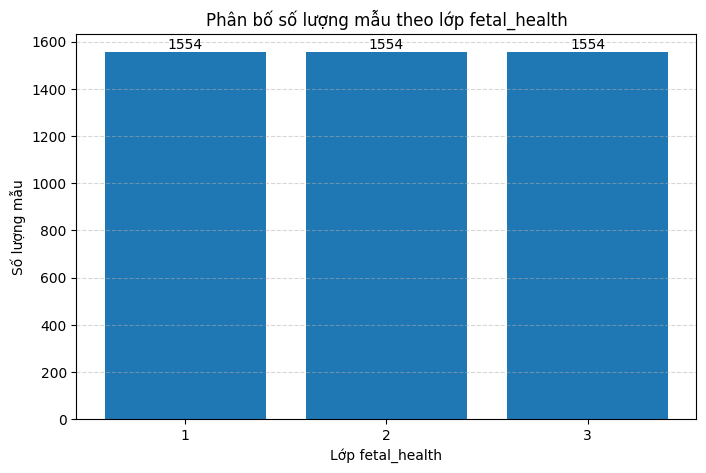

In [19]:
import matplotlib.pyplot as plt

# Đếm số lượng mẫu của từng lớp
class_counts = df_smote['fetal_health'].value_counts().sort_index()

# Vẽ biểu đồ cột
plt.figure(figsize=(8,5))
bars = plt.bar(class_counts.index.astype(str), class_counts.values)

# Hiển thị số trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval),
             ha='center', va='bottom', fontsize=10)

plt.title('Phân bố số lượng mẫu theo lớp fetal_health')
plt.xlabel('Lớp fetal_health')
plt.ylabel('Số lượng mẫu')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()